# 11. Season & Episode Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I aggregated engagement and drop-off metrics by season and episode number, ranked seasons, and measured where drop-off rises between episode positions.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


In [2]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
# Engagement score based on the formula provided in the project brief.
# Watch percentage is already on a 0-100 scale, while the 1-10 content scores
# are multiplied by 5 before combining them.
df["engagement_score"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

df["engagement_score"].describe()

count    33171.000000
mean        70.734135
std         12.023213
min         30.000000
25%         62.500000
50%         71.000000
75%         79.500000
max        117.500000
Name: engagement_score, dtype: float64

In [3]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

## Season-Level Performance

In [4]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
season_summary = (
    df.groupby("season_number")
    .agg(
        episodes=("show_id", "size"),
        avg_engagement=("engagement_score", "mean"),
        avg_watch=("avg_watch_percentage", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
    .sort_values("avg_engagement", ascending=False)
)
season_summary["drop_off_rate_pct"] = season_summary["drop_off_rate"] * 100
display(season_summary)

best_season = season_summary.iloc[0]
print("Highest-engagement season number:", best_season["season_number"])
print("Average engagement:", round(best_season["avg_engagement"], 2))

,season_number,episodes,avg_engagement,avg_watch,avg_drop_off_probability,drop_off_rate,drop_off_rate_pct
0,1,33171,70.734135,56.805764,0.478433,0.144825,14.48253


Highest-engagement season number: 1.0
Average engagement: 70.73


## Show + Season Performance

In [5]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
show_season = (
    df.groupby(["title", "season_number"])
    .agg(
        episodes=("episode_number", "size"),
        avg_engagement=("engagement_score", "mean"),
        avg_watch=("avg_watch_percentage", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean")
    )
    .reset_index()
    .sort_values("avg_engagement", ascending=False)
)
display(show_season.head(20))

,title,season_number,episodes,avg_engagement,avg_watch,avg_drop_off_probability
90,DAS!,1,1,98.500000,87.000000,0.218000
329,Seinfeld,1,5,91.700000,79.400000,0.303800
443,The White Lotus,1,6,86.333333,72.666667,0.363833
25,America's Great Divide: From Obama to Trump,1,2,86.250000,77.500000,0.321500
192,Karma,1,6,84.083333,69.833333,0.388167
64,Californication,1,12,83.666667,71.916667,0.355583
88,Curb Your Enthusiasm,1,10,81.850000,68.700000,0.365900
92,Dallas,1,5,81.200000,68.400000,0.377000
3,30 Rock,1,21,81.071429,65.952381,0.409143
327,Sean Combs: The Reckoning,1,4,81.000000,65.750000,0.395250


## Episode-Number Pattern

,episode_number,observations,avg_engagement,avg_watch,drop_off_rate,avg_drop_off_probability,drop_off_rate_pct
0,1,500,79.516000,64.942000,0.036000,0.412126,3.600000
1,2,497,70.496982,56.305835,0.179074,0.482139,17.907445
2,3,492,69.899390,56.343496,0.140244,0.481374,14.024390
3,4,487,70.191992,56.410678,0.162218,0.480963,16.221766
4,5,484,70.082645,55.723140,0.154959,0.487494,15.495868
5,6,479,69.919624,56.050104,0.167015,0.483610,16.701461
6,7,456,69.785088,56.061404,0.168860,0.488007,16.885965
7,8,445,70.369663,55.907865,0.182022,0.484461,18.202247
8,9,395,70.444304,56.812658,0.146835,0.476365,14.683544
9,10,378,71.203704,56.997354,0.153439,0.476749,15.343915


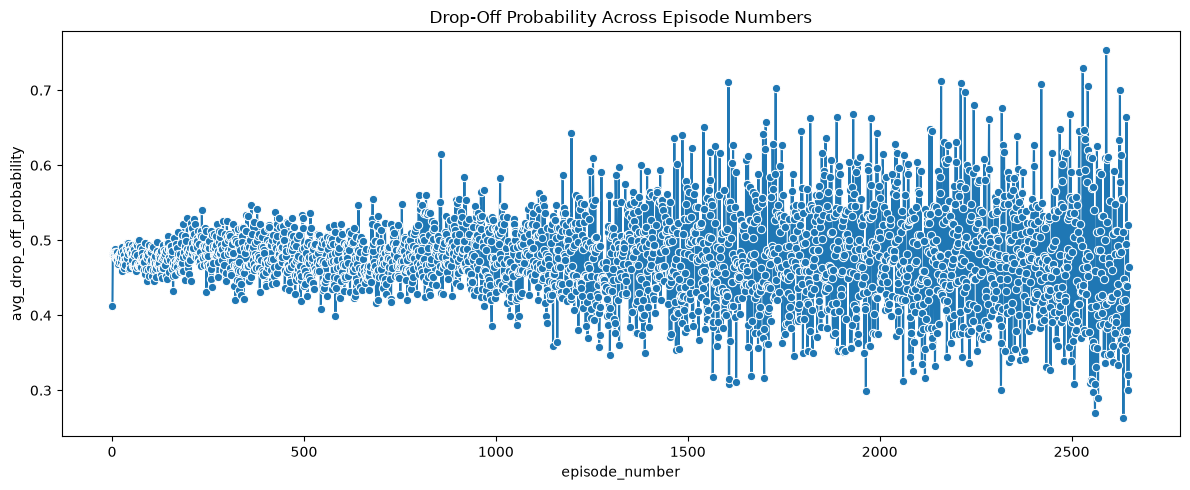

In [6]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
episode_pattern = (
    df.groupby("episode_number")
    .agg(
        observations=("show_id", "size"),
        avg_engagement=("engagement_score", "mean"),
        avg_watch=("avg_watch_percentage", "mean"),
        drop_off_rate=("drop_off", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean")
    )
    .reset_index()
    .sort_values("episode_number")
)
episode_pattern["drop_off_rate_pct"] = episode_pattern["drop_off_rate"] * 100
display(episode_pattern.head(30))

plt.figure(figsize=(12, 5))
sns.lineplot(data=episode_pattern, x="episode_number",
             y="avg_drop_off_probability", marker="o")
plt.title("Drop-Off Probability Across Episode Numbers")
plt.tight_layout()
plt.show()
plt.close()

## Where Does Drop-Off Increase?

In [7]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
episode_pattern["dropoff_change"] = episode_pattern["avg_drop_off_probability"].diff()

increases = (
    episode_pattern[episode_pattern["dropoff_change"] > 0]
    .sort_values("dropoff_change", ascending=False)
    [["episode_number", "observations", "avg_drop_off_probability", "dropoff_change"]]
)
display(increases.head(15))

,episode_number,observations,avg_drop_off_probability,dropoff_change
2589,2590,1,0.7540,0.3390
2420,2421,2,0.7090,0.3185
1699,1700,2,0.6220,0.3050
2210,2211,2,0.7095,0.3050
2317,2318,2,0.6765,0.2905
2244,2245,2,0.6805,0.2875
1818,1819,2,0.6635,0.2845
2135,2136,2,0.6455,0.2755
2587,2588,1,0.6100,0.2740
2565,2566,1,0.6260,0.2690


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Key Interpretation

The dataset contains Season 1 observations, so the season comparison is limited: Season 1 has an average engagement score of about **70.73**. Episode-number analysis is still useful for identifying positions where drop-off probability rises, but it should not be described as a cross-season comparison when only one season number is represented.

## Episode Progression Analysis

Grouping all Episode 1s, Episode 2s, and so on helps identify structural patterns across shows.  
The change columns show where watch completion falls or drop-off probability rises relative to the previous episode number.

In [8]:
episode_progression = (
    df.groupby("episode_number")
    .agg(
        observations=("episode_number", "count"),
        avg_watch=("avg_watch_percentage", "mean"),
        median_watch=("avg_watch_percentage", "median"),
        avg_drop_probability=("drop_off_probability", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
    .sort_values("episode_number")
)

episode_progression["watch_change"] = (
    episode_progression["avg_watch"].diff()
)

episode_progression["drop_probability_change"] = (
    episode_progression["avg_drop_probability"].diff()
)

episode_progression["drop_off_rate_pct"] = (
    episode_progression["drop_off_rate"] * 100
)

display(episode_progression.head(30).round(3))

print("\nLargest increases in drop-off probability:")
display(
    episode_progression
    .sort_values("drop_probability_change", ascending=False)
    .head(10)
    .round(3)
)

,episode_number,observations,avg_watch,median_watch,avg_drop_probability,drop_off_rate,watch_change,drop_probability_change,drop_off_rate_pct
0,1,500,64.942,65.0,0.412,0.036,NaN,NaN,3.600
1,2,497,56.306,57.0,0.482,0.179,-8.636,0.070,17.907
2,3,492,56.343,56.0,0.481,0.140,0.038,-0.001,14.024
3,4,487,56.411,56.0,0.481,0.162,0.067,-0.000,16.222
4,5,484,55.723,56.0,0.487,0.155,-0.688,0.007,15.496
5,6,479,56.050,57.0,0.484,0.167,0.327,-0.004,16.701
6,7,456,56.061,56.0,0.488,0.169,0.011,0.004,16.886
7,8,445,55.908,57.0,0.484,0.182,-0.154,-0.004,18.202
8,9,395,56.813,58.0,0.476,0.147,0.905,-0.008,14.684
9,10,378,56.997,57.0,0.477,0.153,0.185,0.000,15.344



Largest increases in drop-off probability:


,episode_number,observations,avg_watch,median_watch,avg_drop_probability,drop_off_rate,watch_change,drop_probability_change,drop_off_rate_pct
2589,2590,1,29.0,29.0,0.754,1.0,-31.0,0.339,100.0
2420,2421,2,33.5,33.5,0.709,1.0,-37.0,0.319,100.0
1699,1700,2,48.0,48.0,0.622,1.0,-26.0,0.305,100.0
2210,2211,2,28.5,28.5,0.710,1.0,-35.5,0.305,100.0
2317,2318,2,33.5,33.5,0.677,1.0,-33.5,0.291,100.0
2244,2245,2,36.5,36.5,0.681,0.5,-24.5,0.288,50.0
1818,1819,2,41.0,41.0,0.664,1.0,-27.5,0.284,100.0
2135,2136,2,41.5,41.5,0.646,0.5,-28.0,0.275,50.0
2587,2588,1,40.0,40.0,0.610,1.0,-31.0,0.274,100.0
2565,2566,1,42.0,42.0,0.626,1.0,-22.0,0.269,100.0


In [9]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
